In [307]:
import os
import requests
import json
import pandas as pd
import math
pd.set_option('display.max_columns', None)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from sklearn import linear_model
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor


import re

## LOAD DATASET

In [10]:
squad_rank_map = {
    # [21-22, 22-23, 23-24, 24-25]
    'Ajaccio': [22, 18, 22, 22], 'Alavés': [20, 22, 10, 12], 'Almería': [22, 17, 19, 22], 'Angers': [14, 20, 22, 18],
    'Arminia': [17, 22, 22, 22], 'Arsenal': [5, 2, 2, 2], 'Aston Villa': [14, 7, 4, 5], 'Atalanta': [8, 5, 4, 3],
    'Athletic Club': [8, 8, 5, 6], 'Atlético Madrid': [3, 3, 4, 3], 'Augsburg': [14, 15, 11, 13], 'Auxerre': [22, 17, 22, 15],
    'Barcelona': [2, 1, 2, 1], 'Bayern Munich': [1, 1, 3, 1], 'Bochum': [13, 14, 16, 17], 'Bologna': [13, 9, 5, 8],
    'Bordeaux': [20, 22, 22, 22],'Bournemouth': [22, 15, 12, 11],'Brentford': [13, 9, 16, 14],'Brest': [11, 14, 3, 9],
    'Brighton': [9, 6, 11, 10],'Burnley': [18, 22, 19, 22],'Cagliari': [18, 22, 16, 16],'Celta Vigo': [11, 13, 14, 11],
    'Chelsea': [3, 12, 6, 4],'Clermont Foot': [17, 8, 18, 22],'Cremonese': [22, 19, 22, 22],'Crystal Palace': [12, 11, 10, 12],
    'Cádiz': [17, 14, 18, 22],'Darmstadt 98': [22, 22, 18, 22],'Dortmund': [2, 2, 5, 4],'Eintracht Frankfurt': [11, 7, 6, 6],
    'Elche': [13, 20, 22, 22],'Empoli': [14, 14, 17, 14],'Espanyol': [14, 19, 22, 17],'Everton': [16, 17, 15, 15],
    'Fiorentina': [7, 8, 8, 7], 'Freiburg': [6, 5, 10, 8], 'Frosinone': [22, 22, 18, 22],
    'Fulham': [22, 10, 13, 12], 'Genoa': [19, 22, 11, 13], 'Getafe': [15, 15, 12, 14], 'Girona': [22, 10, 3, 7],
    'Gladbach': [10, 10, 14, 11], 'Granada': [18, 22, 20, 22], 'Greuther Fürth': [18, 22, 22, 22], 'Heidenheim': [22, 22, 8, 12],
    'Hellas Verona': [9, 18, 13, 15], 'Hertha BSC': [16, 18, 22, 22], 'Hoffenheim': [9, 12, 7, 10], 'Inter': [2, 3, 1, 2],
    'Juventus': [4, 7, 3, 3], 'Köln': [7, 11, 17, 22], 'Las Palmas': [22, 22, 16, 17], 'Lazio': [5, 2, 7, 6],
    'Le Havre': [22, 22, 15, 16], 'Lecce': [22, 16, 14, 15], 'Leeds United': [17, 19, 22, 22], 'Leicester City': [8, 18, 22, 16],
    'Lens': [7, 2, 7, 8], 'Levante': [19, 22, 22, 22], 'Leverkusen': [3, 6, 1, 3], 'Lille': [10, 5, 4, 5],
    'Liverpool': [2, 5, 3, 1], 'Lorient': [16, 10, 19, 22], 'Luton Town': [22, 22, 18, 22], 'Lyon': [8, 7, 6, 6],
    'Mainz 05': [8, 9, 13, 12], 'Mallorca': [16, 9, 15, 13], 'Manchester City': [1, 1, 1, 2], 'Manchester Utd': [6, 3, 8, 7],
    'Marseille': [2, 3, 8, 5], 'Metz': [19, 22, 18, 22], 'Milan': [1, 4, 2, 4], 'Monaco': [3, 6, 2, 2],
    'Montpellier': [13, 12, 12, 14], 'Monza': [22, 11, 12, 15], 'Nantes': [9, 16, 14, 16], 'Napoli': [3, 1, 10, 4],
    'Newcastle United': [11, 4, 7, 6], 'Nice': [5, 9, 5, 6], 'Norwich City': [20, 22, 22, 22], 'Nottingham Forest': [22, 16, 17, 14],
    'Osasuna': [10, 7, 11, 10], 'Paris Saint-Germain': [1, 1, 1, 1], 'RB Leipzig': [4, 3, 4, 4], 'Rayo Vallecano': [12, 11, 17, 15],
    'Real Betis': [5, 6, 7, 7], 'Real Madrid': [1, 2, 1, 2], 'Real Sociedad': [6, 4, 6, 8], 'Reims': [12, 11, 9, 10],
    'Rennes': [4, 4, 10, 9], 'Roma': [6, 6, 6, 7], 'Saint-Étienne': [18, 22, 22, 16], 'Salernitana': [17, 15, 20, 22],
    'Sampdoria': [15, 20, 22, 22], 'Sassuolo': [11, 13, 19, 22], 'Schalke 04': [22, 17, 22, 22], 'Sevilla': [4, 12, 14, 12],
    'Sheffield United': [22, 22, 20, 22], 'Southampton': [15, 20, 22, 19], 'Spezia': [16, 18, 22, 22],'Strasbourg': [6, 15, 13, 13],
    'Stuttgart': [15, 16, 2, 7],'Torino': [10, 10, 9, 11], 'Tottenham Hotspur': [4, 8, 5, 5],'Toulouse': [22, 13, 11, 12],
    'Troyes': [15, 19, 22, 22],'Udinese': [12, 12, 15, 13], 'Union Berlin': [5, 4, 15, 11],'Valencia': [9, 14, 9, 13],
    'Valladolid': [22, 18, 22, 19],'Venezia': [20, 22, 22, 20], 'Villarreal': [7, 5, 8, 6],'Watford': [19, 22, 22, 22],
    'Werder Bremen': [22, 13, 9, 10],'West Ham United': [7, 14, 9, 11], 'Wolfsburg': [12, 8, 12, 12],'Wolves': [10, 13, 14, 15],
}

def get_squad_rank_map(year, full_map=squad_rank_map):
    index = year - 2021
    if (index < 0 or index >= len(full_map)):
        print("No Data For That Year")
        return

    temp_dict = {}
    for squad in full_map:
        temp_dict[squad] = full_map[squad][index]
        
    return temp_dict

In [90]:
def apply_squad_rank(df, year):
    df = df.copy()
    rank_map_for_year = get_squad_rank_map(year)
    
    if rank_map_for_year is None:
        return df

    df['Squad_Rank'] = df['Unnamed: 4_level_0_Squad'].map(rank_map_for_year).apply(lambda x: 21 - x if pd.notnull(x) else 0)
    df = df.drop(columns=['Unnamed: 4_level_0_Squad'])
    
    return df

def clean_dataframe(df):
    df = df.dropna(subset = ["Value (€)"])
    df = df.drop(columns = ["Name_Clean", 
                            "Unnamed: 0_y", 
                            "Name_y", 
                            "Unnamed: 0_x", 
                            "Unnamed: 0_level_0_Rk", 
                            "Unnamed: 24_level_0_Matches",
                            "Unnamed: 0"
                           ])
    df = df.rename(columns={
        'Unnamed: 3_level_0_Pos': 'Position', 
        'Unnamed: 5_level_0_Age': 'Age',
        'Unnamed: 6_level_0_Born': 'Born',
        'Unnamed: 2_level_0_Nation': 'Nationality',
        'Playing Time_MP': 'Match Played',
        'Name_x': 'Name',
        'Playing Time_Starts': 'Match Started',
        'Playing Time_Min': 'Minutes Played',
        'Playing Time_90s': 'Minutes Played / 90',
        'Performance_Gls': 'Goals',
        'Performance_Ast': 'Assists',
        'Performance_G+A': 'Goals + Assists',
        'Performance_G-PK': 'Non-Penality Goals',
        'Performance_PK': 'Penalty Kick Goals',
        'Performance_PKatt': 'Penalty Kick Attempted',
        'Performance_CrdY': 'Yellow Cards',
        'Performance_CrdR': 'Red Cards',
        'Per 90 Minutes_Gls': 'Goals Per 90 Minutes',
        'Per 90 Minutes_Ast': 'Assists Per 90 Minutes',
        'Per 90 Minutes_G+A': 'G+A Per 90 Minutes',
        'Per 90 Minutes_G-PK': 'Non-Penality Goals Per 90 Minutes',
        'Per 90 Minutes_G+A-PK': 'Non-Penalty Goals + Assists/90',
        'Value (€)': 'Value',
        # '': '',
        # '': '',
        # '': '',
        # '': '',
        # '': '',
        # '': '',
    })

    intger_column_list = ["Age", "Born", "Match Played", "Match Started", "Minutes Played", "Goals", "Assists", "Goals + Assists", 
                  "Non-Penality Goals", "Penalty Kick Goals", "Penalty Kick Attempted", "Yellow Cards", "Red Cards"]
    
    float_column_list = ["Minutes Played / 90", "Goals Per 90 Minutes", "Assists Per 90 Minutes", 
                  "G+A Per 90 Minutes", "Non-Penality Goals Per 90 Minutes", "Non-Penalty Goals + Assists/90"]

    numeric_column_list = []
    numeric_column_list.extend(intger_column_list)
    numeric_column_list.extend(float_column_list)

    for column in numeric_column_list:
        df[column] = pd.to_numeric(df[column], errors='coerce')
    
    return df

def preprocess_dataframe(df):
    df = df.copy()

    df_rest = df.drop(columns=["Value"])
    
    scaler = StandardScaler()
    numeric_cols = df_rest.select_dtypes(include=['float64', 'int64']).columns
    scaler.fit(df[numeric_cols])
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

    position_dummies = df['Position'].str.get_dummies(sep=',')
    df = pd.concat([df, position_dummies], axis=1)   
    df = df.set_index('Name')
    df = df.drop(columns = ["Nationality", "Born", "Position"])

    df = df[[c for c in df.columns if c != "Value"] + ["Value"]]
    return df, scaler

def end_to_end_process_data(df, year):
    df = apply_squad_rank(df, year)
    df = clean_dataframe(df)
    df, _ = preprocess_dataframe(df)
    return df

def end_to_end_load_data(filename):
    df = pd.read_csv(filename)
    year = int("".join(re.findall(r'\d+', filename)))

    df = end_to_end_process_data(df, year)

    return df

def divide_position(df):
    position_dummies = df['Position'].str.get_dummies(sep=',')
    return pd.concat([df, position_dummies], axis=1)

def load_raw_data(filepath, year, folder_path = "Datasets"):
    return apply_squad_rank(divide_position(clean_dataframe(pd.read_csv(os.path.join(folder_path, filepath)))).drop(columns=["Position", "Name", "Nationality", "Born"]), year)

In [92]:
test_2024 = load_raw_data("test_2024.csv", 2024)
train_2023 = load_raw_data("train_2023.csv", 2023)
train_2022 = load_raw_data("train_2022.csv", 2022)
train_2021 = load_raw_data("train_2021.csv", 2021)

In [94]:
test_2024.head()

,Age,Match Played,Match Started,Minutes Played,Minutes Played / 90,Goals,Assists,Goals + Assists,Non-Penality Goals,Penalty Kick Goals,Penalty Kick Attempted,Yellow Cards,Red Cards,Goals Per 90 Minutes,Assists Per 90 Minutes,G+A Per 90 Minutes,Non-Penality Goals Per 90 Minutes,Non-Penalty Goals + Assists/90,Value,DF,FW,GK,MF,Squad_Rank
2,25,28,21,1965,21.8,0,3,3,0,0,0,7,0,0.00,0.14,0.14,0.00,0.14,25000000.0,0,0,0,1,10.0
3,26,22,15,1409,15.7,1,1,2,1,0,0,4,0,0.06,0.06,0.13,0.06,0.13,20000000.0,1,0,0,0,17.0
4,22,29,12,1097,12.2,2,2,4,2,0,0,0,0,0.16,0.16,0.33,0.16,0.33,22000000.0,0,0,0,1,11.0
7,27,35,35,2995,33.3,2,1,3,2,0,0,5,0,0.06,0.03,0.09,0.06,0.09,20000000.0,1,0,0,0,7.0
8,23,37,37,3109,34.5,4,7,11,4,0,0,7,1,0.12,0.20,0.32,0.12,0.32,40000000.0,1,0,0,1,6.0


In [234]:
df = pd.concat([train_2023, train_2022, train_2021], axis=0)

In [236]:
df.info()

<class 'pandas.DataFrame'>
Index: 5613 entries, 0 to 3035
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                5613 non-null   int64  
 1   Match Played                       5613 non-null   int64  
 2   Match Started                      5613 non-null   int64  
 3   Minutes Played                     5613 non-null   int64  
 4   Minutes Played / 90                5613 non-null   float64
 5   Goals                              5613 non-null   int64  
 6   Assists                            5613 non-null   int64  
 7   Goals + Assists                    5613 non-null   int64  
 8   Non-Penality Goals                 5613 non-null   int64  
 9   Penalty Kick Goals                 5613 non-null   int64  
 10  Penalty Kick Attempted             5613 non-null   int64  
 11  Yellow Cards                       5613 non-null   int64  
 12  Red Card

In [238]:
round(df.describe(), 2)

,Age,Match Played,Match Started,Minutes Played,Minutes Played / 90,Goals,Assists,Goals + Assists,Non-Penality Goals,Penalty Kick Goals,Penalty Kick Attempted,Yellow Cards,Red Cards,Goals Per 90 Minutes,Assists Per 90 Minutes,G+A Per 90 Minutes,Non-Penality Goals Per 90 Minutes,Non-Penalty Goals + Assists/90,Value,DF,FW,GK,MF,Squad_Rank
count,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5.613000e+03,5613.00,5613.00,5613.00,5613.00,5613.00
mean,25.04,21.26,15.88,1419.02,15.77,2.08,1.45,3.53,1.89,0.19,0.23,2.96,0.13,0.13,0.09,0.22,0.12,0.21,1.352680e+07,0.36,0.26,0.08,0.55,11.79
std,4.35,11.19,11.36,969.36,10.77,3.56,2.15,5.05,3.13,0.78,0.91,2.80,0.38,0.23,0.22,0.33,0.22,0.32,1.948022e+07,0.48,0.44,0.27,0.50,5.43
min,15.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.000000e+04,0.00,0.00,0.00,0.00,1.00
25%,22.00,12.00,5.00,535.00,5.90,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,2.500000e+06,0.00,0.00,0.00,0.00,7.00
50%,25.00,23.00,15.00,1397.00,15.50,1.00,1.00,2.00,1.00,0.00,0.00,2.00,0.00,0.04,0.03,0.12,0.04,0.12,6.000000e+06,0.00,0.00,0.00,1.00,12.00
75%,28.00,31.00,26.00,2208.00,24.50,3.00,2.00,5.00,2.00,0.00,0.00,5.00,0.00,0.17,0.13,0.32,0.16,0.31,1.800000e+07,1.00,1.00,0.00,1.00,16.00
max,41.00,38.00,38.00,3420.00,38.00,36.00,18.00,45.00,31.00,10.00,11.00,16.00,3.00,4.50,11.25,11.25,4.50,11.25,2.000000e+08,1.00,1.00,1.00,1.00,20.00


## POSITION DISTRIBUTION

In [130]:
position_df = df[["DF", "FW", "GK", "MF"]]

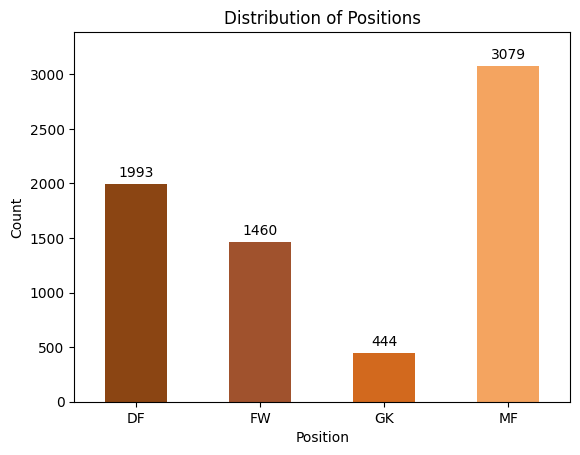

In [185]:
ax = position_df.sum().plot(kind='bar', color=['saddlebrown', 'sienna', 'chocolate', 'sandybrown'])
ax.bar_label(ax.containers[0], label_type='edge', padding=3)

plt.title("Distribution of Positions")
plt.xlabel("Position")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.ylim(0, position_df.sum().max() * 1.1)
plt.show()

## STAT DISTRIBUTION

In [395]:
def plot_distribution(df, column_name, figsize=(10, 6), color='lightskyblue', discrete=False, ax=None, show_count=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.histplot(df[column_name], kde=True, color=color, discrete=discrete, ax=ax)
    ax.set_title(f'{column_name} distribution', fontsize=12)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

    data = df[column_name].dropna()
    d_min = data.min()
    d_mean = data.mean()
    d_max = data.max()

    ax.axvline(d_min, color='red', linestyle='--', linewidth=1, label=f'Min: {d_min:.1f}', alpha=0)
    ax.axvline(d_mean, color='black', linestyle='-', linewidth=2, label=f'Mean: {d_mean:.1f}', alpha=0.3)
    ax.axvline(d_max, color='blue', linestyle='--', linewidth=1, label=f'Max: {d_max:.1f}', alpha=0)

    ax.legend()

    if show_count:
        ax.bar_label(ax.containers[0], label_type='edge', padding=3, fontsize=6)
    
    heights = [p.get_height() for p in ax.patches]
    if heights:
        max_height = max(heights)
        ax.set_ylim(0, max_height * 1.1)

In [397]:
discrete_column_list = ["Age", "Born", "Match Played", "Match Started", "Goals", "Assists", "Goals + Assists", 
                  "Non-Penality Goals", "Penalty Kick Goals", "Penalty Kick Attempted", "Yellow Cards", "Red Cards"]

def plot_entire_distribution(df, color='lightskyblue'):
    cols_to_plot = [col for col in df.columns if col not in ["DF", "FW", "GK", "MF"]]
    
    n_cols = 3
    n_rows = math.ceil(len(cols_to_plot) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
    axes = axes.flatten()
    
    for i, column in enumerate(cols_to_plot):
        plot_distribution(df, column, color=color, discrete=(column in discrete_column_list), ax=axes[i])
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

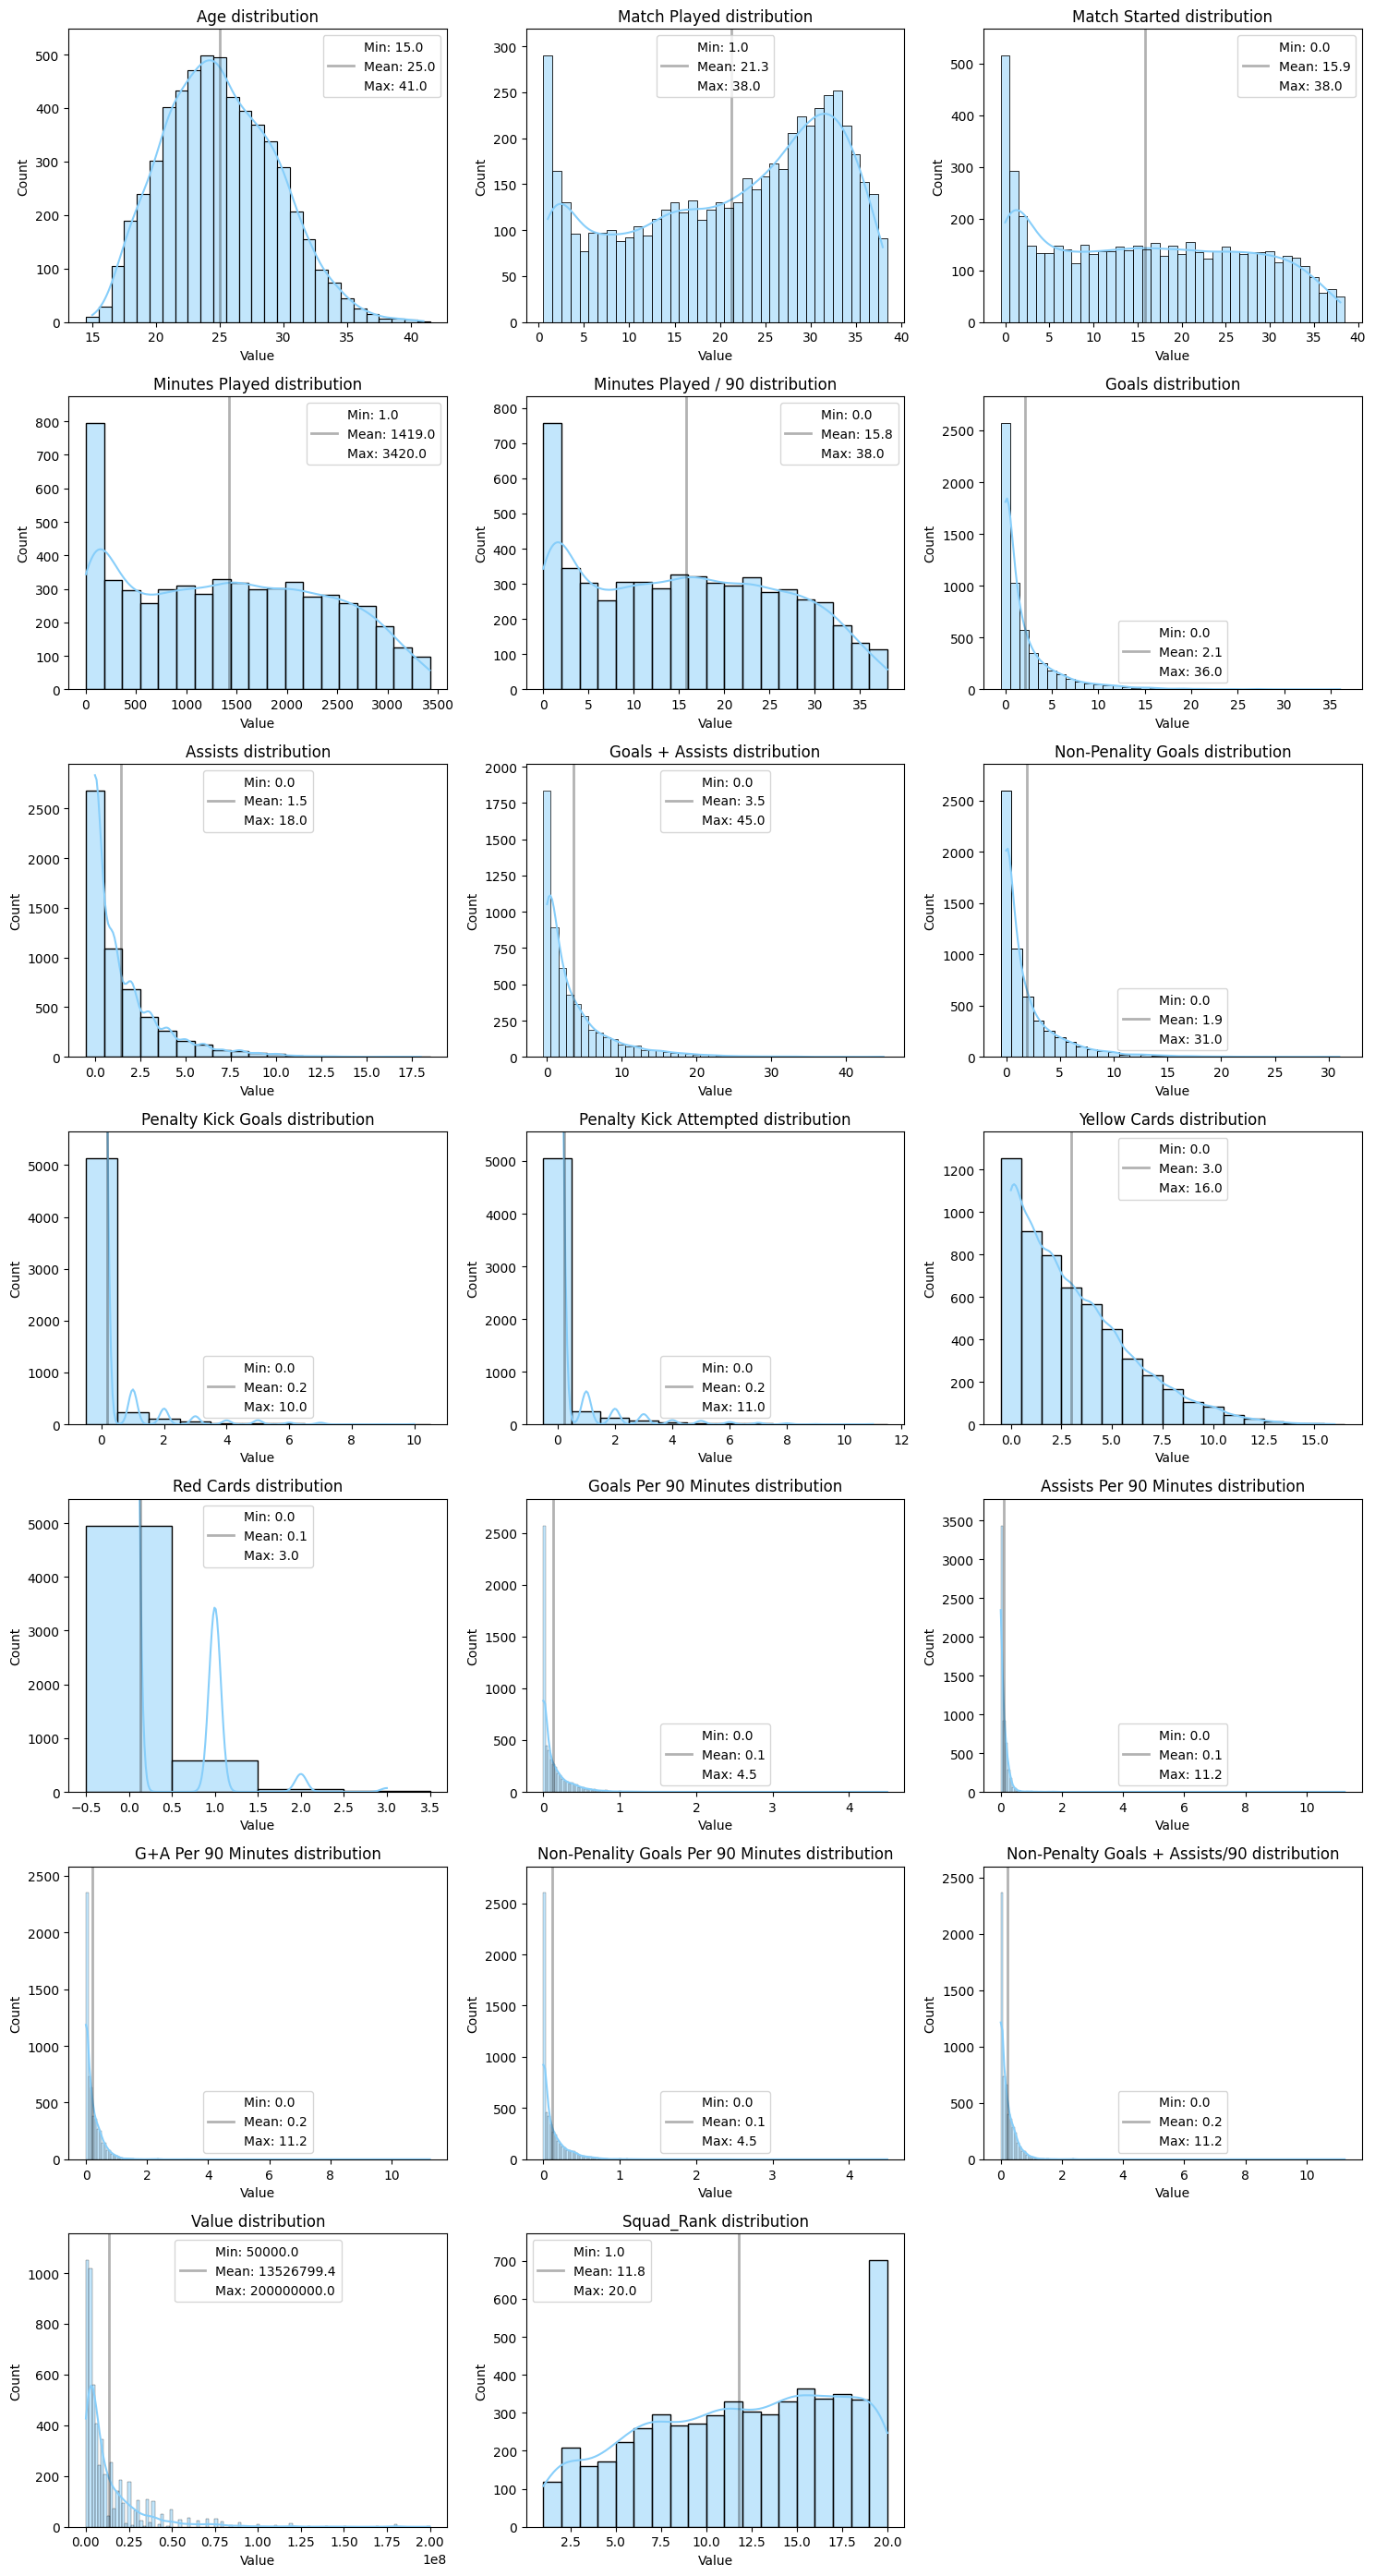

In [399]:
plot_entire_distribution(df)

## STAT DISTRIBUTION PER POSITION

In [187]:
DF_df = df[df["DF"] == 1]
FW_df = df[df["FW"] == 1]
GK_df = df[df["GK"] == 1]
DF_df = df[df["MF"] == 1]

In [189]:
round(DF_df.drop(columns=["DF", "FW", "GK", "MF"]).describe(), 2)

,Age,Match Played,Match Started,Minutes Played,Minutes Played / 90,Goals,Assists,Goals + Assists,Non-Penality Goals,Penalty Kick Goals,Penalty Kick Attempted,Yellow Cards,Red Cards,Goals Per 90 Minutes,Assists Per 90 Minutes,G+A Per 90 Minutes,Non-Penality Goals Per 90 Minutes,Non-Penalty Goals + Assists/90,Value,Squad_Rank
count,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3.079000e+03,3079.00
mean,24.47,21.87,15.23,1356.04,15.07,2.19,1.88,4.06,2.00,0.19,0.22,3.12,0.12,0.13,0.12,0.25,0.12,0.24,1.450304e+07,11.65
std,4.07,10.85,10.80,904.68,10.05,3.08,2.35,4.81,2.76,0.78,0.87,2.86,0.36,0.21,0.28,0.36,0.20,0.35,2.048737e+07,5.41
min,15.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.000000e+04,1.00
25%,21.00,13.00,6.00,554.50,6.20,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.04,0.00,0.03,2.500000e+06,7.00
50%,24.00,24.00,15.00,1352.00,15.00,1.00,1.00,2.00,1.00,0.00,0.00,2.00,0.00,0.07,0.08,0.18,0.07,0.18,7.000000e+06,12.00
75%,27.00,31.00,24.00,2085.50,23.20,3.00,3.00,6.00,3.00,0.00,0.00,5.00,0.00,0.19,0.17,0.36,0.18,0.35,1.800000e+07,16.00
max,40.00,38.00,38.00,3378.00,37.50,36.00,18.00,44.00,29.00,10.00,11.00,15.00,3.00,4.09,11.25,11.25,4.09,11.25,2.000000e+08,20.00


In [191]:
round(FW_df.drop(columns=["DF", "FW", "GK", "MF"]).describe(), 2)

,Age,Match Played,Match Started,Minutes Played,Minutes Played / 90,Goals,Assists,Goals + Assists,Non-Penality Goals,Penalty Kick Goals,Penalty Kick Attempted,Yellow Cards,Red Cards,Goals Per 90 Minutes,Assists Per 90 Minutes,G+A Per 90 Minutes,Non-Penality Goals Per 90 Minutes,Non-Penalty Goals + Assists/90,Value,Squad_Rank
count,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1.460000e+03,1460.00
mean,24.53,21.92,13.95,1257.00,13.97,4.78,2.23,7.01,4.24,0.54,0.67,2.39,0.09,0.30,0.14,0.44,0.27,0.41,1.761361e+07,11.62
std,4.29,11.12,10.78,894.01,9.93,5.36,2.62,7.10,4.62,1.27,1.49,2.42,0.31,0.33,0.19,0.39,0.32,0.38,2.576122e+07,5.52
min,15.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.000000e+04,1.00
25%,21.00,13.75,4.00,453.75,5.00,1.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.09,0.00,0.20,0.08,0.19,2.950000e+06,7.00
50%,24.00,24.00,13.00,1199.00,13.35,3.00,1.00,5.00,3.00,0.00,0.00,2.00,0.00,0.25,0.10,0.41,0.22,0.38,8.000000e+06,12.00
75%,27.00,32.00,22.25,1956.75,21.72,7.00,3.00,10.00,6.00,0.00,1.00,4.00,0.00,0.42,0.21,0.60,0.39,0.56,2.200000e+07,16.00
max,39.00,38.00,38.00,3405.00,37.80,36.00,17.00,45.00,31.00,10.00,11.00,13.00,2.00,4.50,4.29,4.50,4.50,4.50,2.000000e+08,20.00


In [126]:
round(GK_df.drop(columns=["DF", "FW", "GK", "MF"]).describe(), 2)

,Age,Match Played,Match Started,Minutes Played,Minutes Played / 90,Goals,Assists,Goals + Assists,Non-Penality Goals,Penalty Kick Goals,Penalty Kick Attempted,Yellow Cards,Red Cards,Goals Per 90 Minutes,Assists Per 90 Minutes,G+A Per 90 Minutes,Non-Penality Goals Per 90 Minutes,Non-Penalty Goals + Assists/90,Value,Squad_Rank
count,444.0,444.00,444.00,444.00,444.00,444.0,444.00,444.00,444.0,444.0,444.0,444.00,444.00,444.0,444.00,444.00,444.0,444.00,444.00,444.00
mean,28.3,19.33,19.14,1721.16,19.12,0.0,0.07,0.07,0.0,0.0,0.0,1.09,0.06,0.0,0.00,0.00,0.0,0.00,7699042.79,11.87
std,4.6,13.86,14.03,1252.75,13.92,0.0,0.26,0.26,0.0,0.0,0.0,1.29,0.24,0.0,0.04,0.04,0.0,0.04,10301990.34,5.55
min,17.0,1.00,0.00,2.00,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.0,0.00,50000.00,1.00
25%,25.0,4.00,4.00,360.00,4.00,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.0,0.00,1000000.00,7.00
50%,28.0,20.50,20.50,1804.00,20.05,0.0,0.00,0.00,0.0,0.0,0.0,1.00,0.00,0.0,0.00,0.00,0.0,0.00,3000000.00,12.00
75%,31.0,33.00,33.00,2970.00,33.00,0.0,0.00,0.00,0.0,0.0,0.0,2.00,0.00,0.0,0.00,0.00,0.0,0.00,10000000.00,17.00
max,41.0,38.00,38.00,3420.00,38.00,0.0,2.00,2.00,0.0,0.0,0.0,7.00,2.00,0.0,0.50,0.50,0.0,0.50,50000000.00,20.00


In [128]:
round(MF_df.drop(columns=["DF", "FW", "GK", "MF"]).describe(), 2)

,Age,Match Played,Match Started,Minutes Played,Minutes Played / 90,Goals,Assists,Goals + Assists,Non-Penality Goals,Penalty Kick Goals,Penalty Kick Attempted,Yellow Cards,Red Cards,Goals Per 90 Minutes,Assists Per 90 Minutes,G+A Per 90 Minutes,Non-Penality Goals Per 90 Minutes,Non-Penalty Goals + Assists/90,Value,Squad_Rank
count,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3079.00,3.079000e+03,3079.00
mean,24.47,21.87,15.23,1356.04,15.07,2.19,1.88,4.06,2.00,0.19,0.22,3.12,0.12,0.13,0.12,0.25,0.12,0.24,1.450304e+07,11.65
std,4.07,10.85,10.80,904.68,10.05,3.08,2.35,4.81,2.76,0.78,0.87,2.86,0.36,0.21,0.28,0.36,0.20,0.35,2.048737e+07,5.41
min,15.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.000000e+04,1.00
25%,21.00,13.00,6.00,554.50,6.20,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.04,0.00,0.03,2.500000e+06,7.00
50%,24.00,24.00,15.00,1352.00,15.00,1.00,1.00,2.00,1.00,0.00,0.00,2.00,0.00,0.07,0.08,0.18,0.07,0.18,7.000000e+06,12.00
75%,27.00,31.00,24.00,2085.50,23.20,3.00,3.00,6.00,3.00,0.00,0.00,5.00,0.00,0.19,0.17,0.36,0.18,0.35,1.800000e+07,16.00
max,40.00,38.00,38.00,3378.00,37.50,36.00,18.00,44.00,29.00,10.00,11.00,15.00,3.00,4.09,11.25,11.25,4.09,11.25,2.000000e+08,20.00


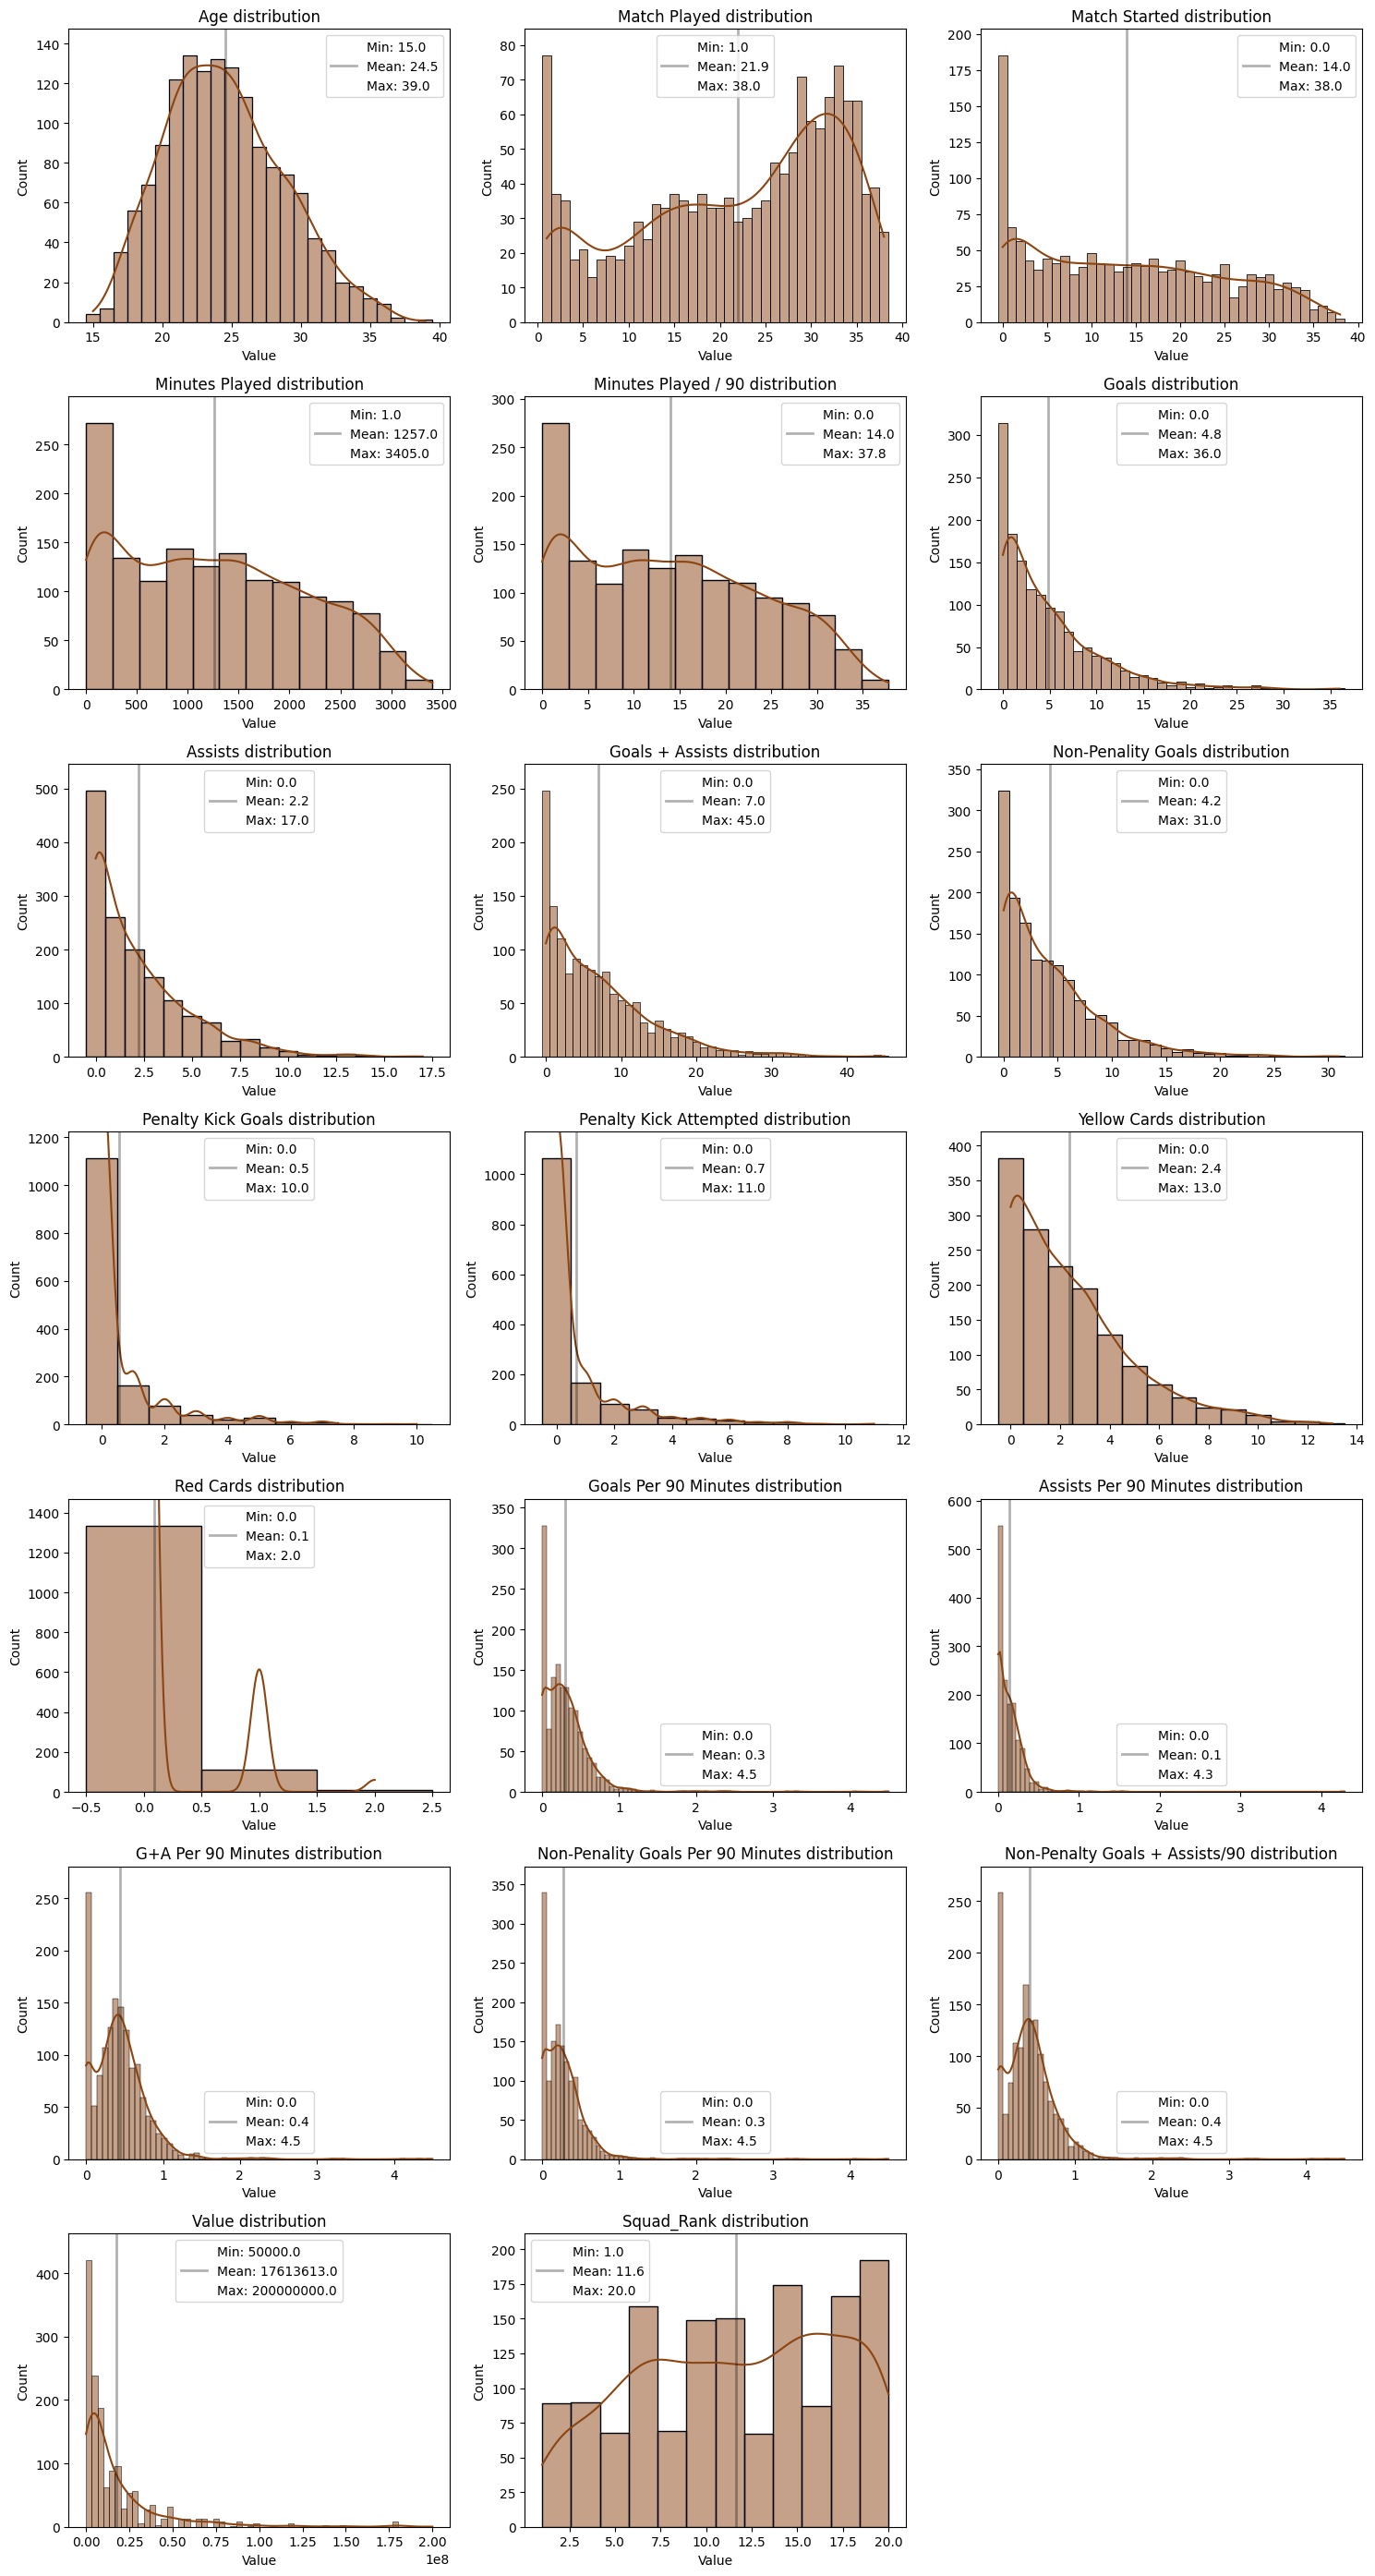

In [401]:
plot_entire_distribution(FW_df, color='saddlebrown')

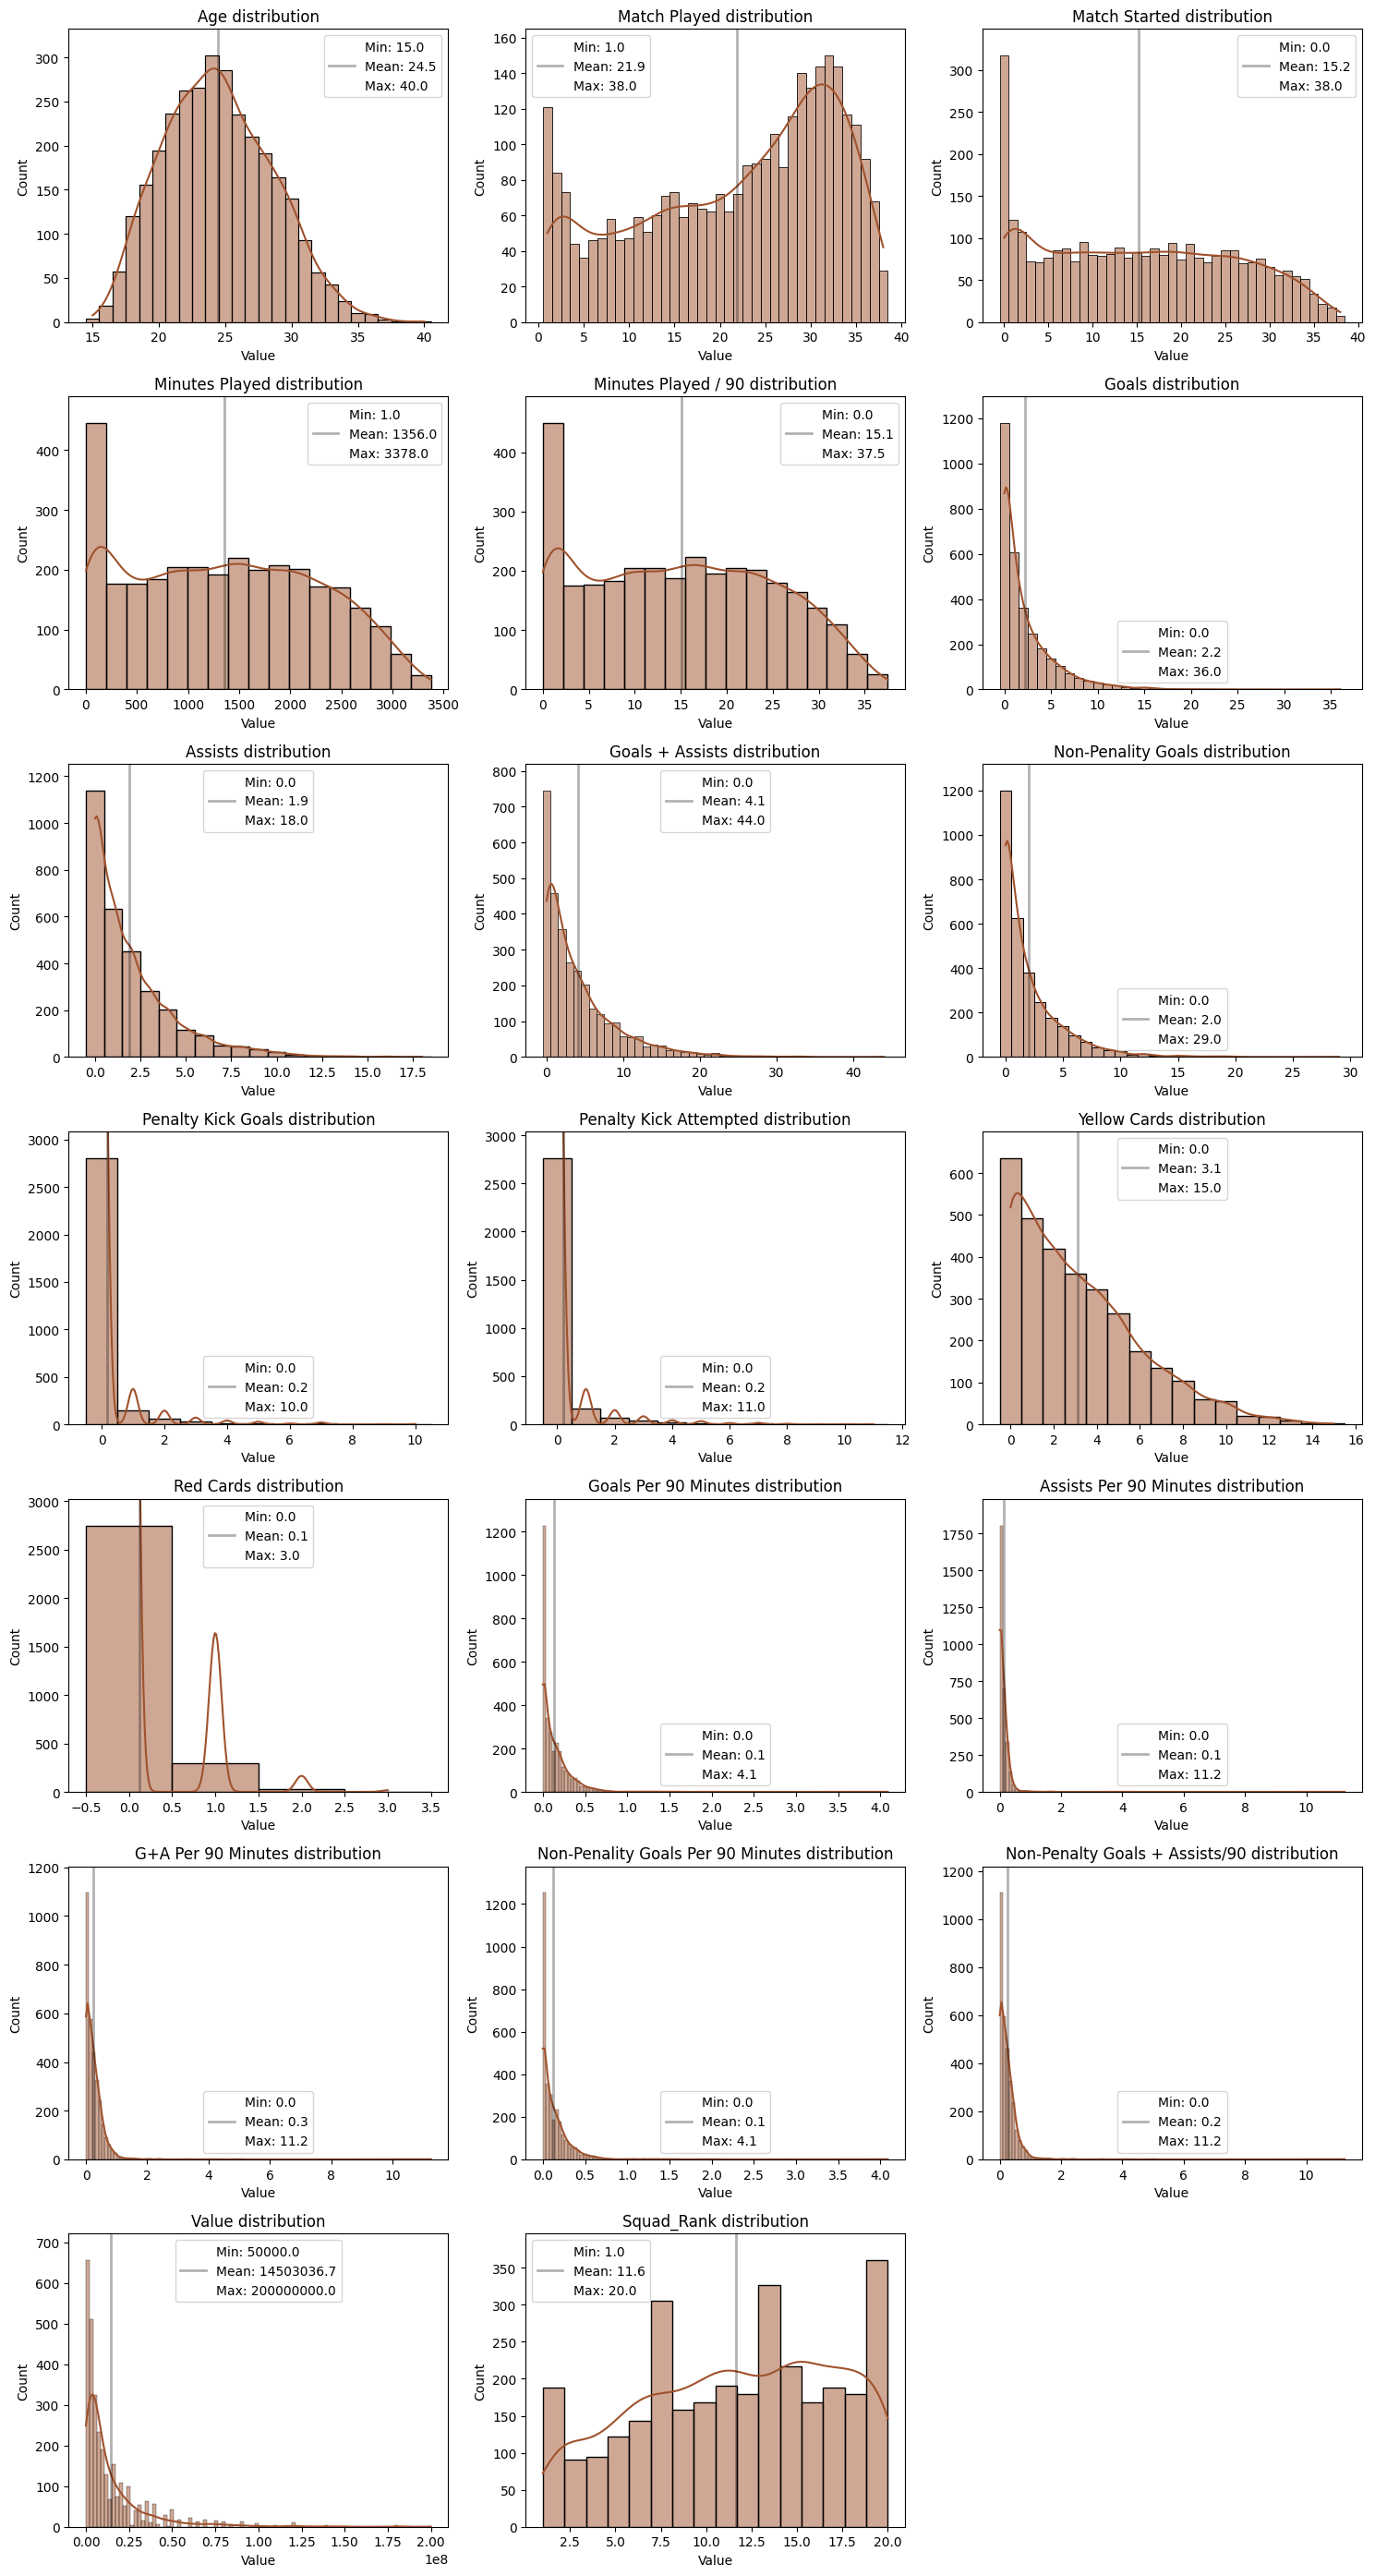

In [402]:
plot_entire_distribution(MF_df, color='sienna')

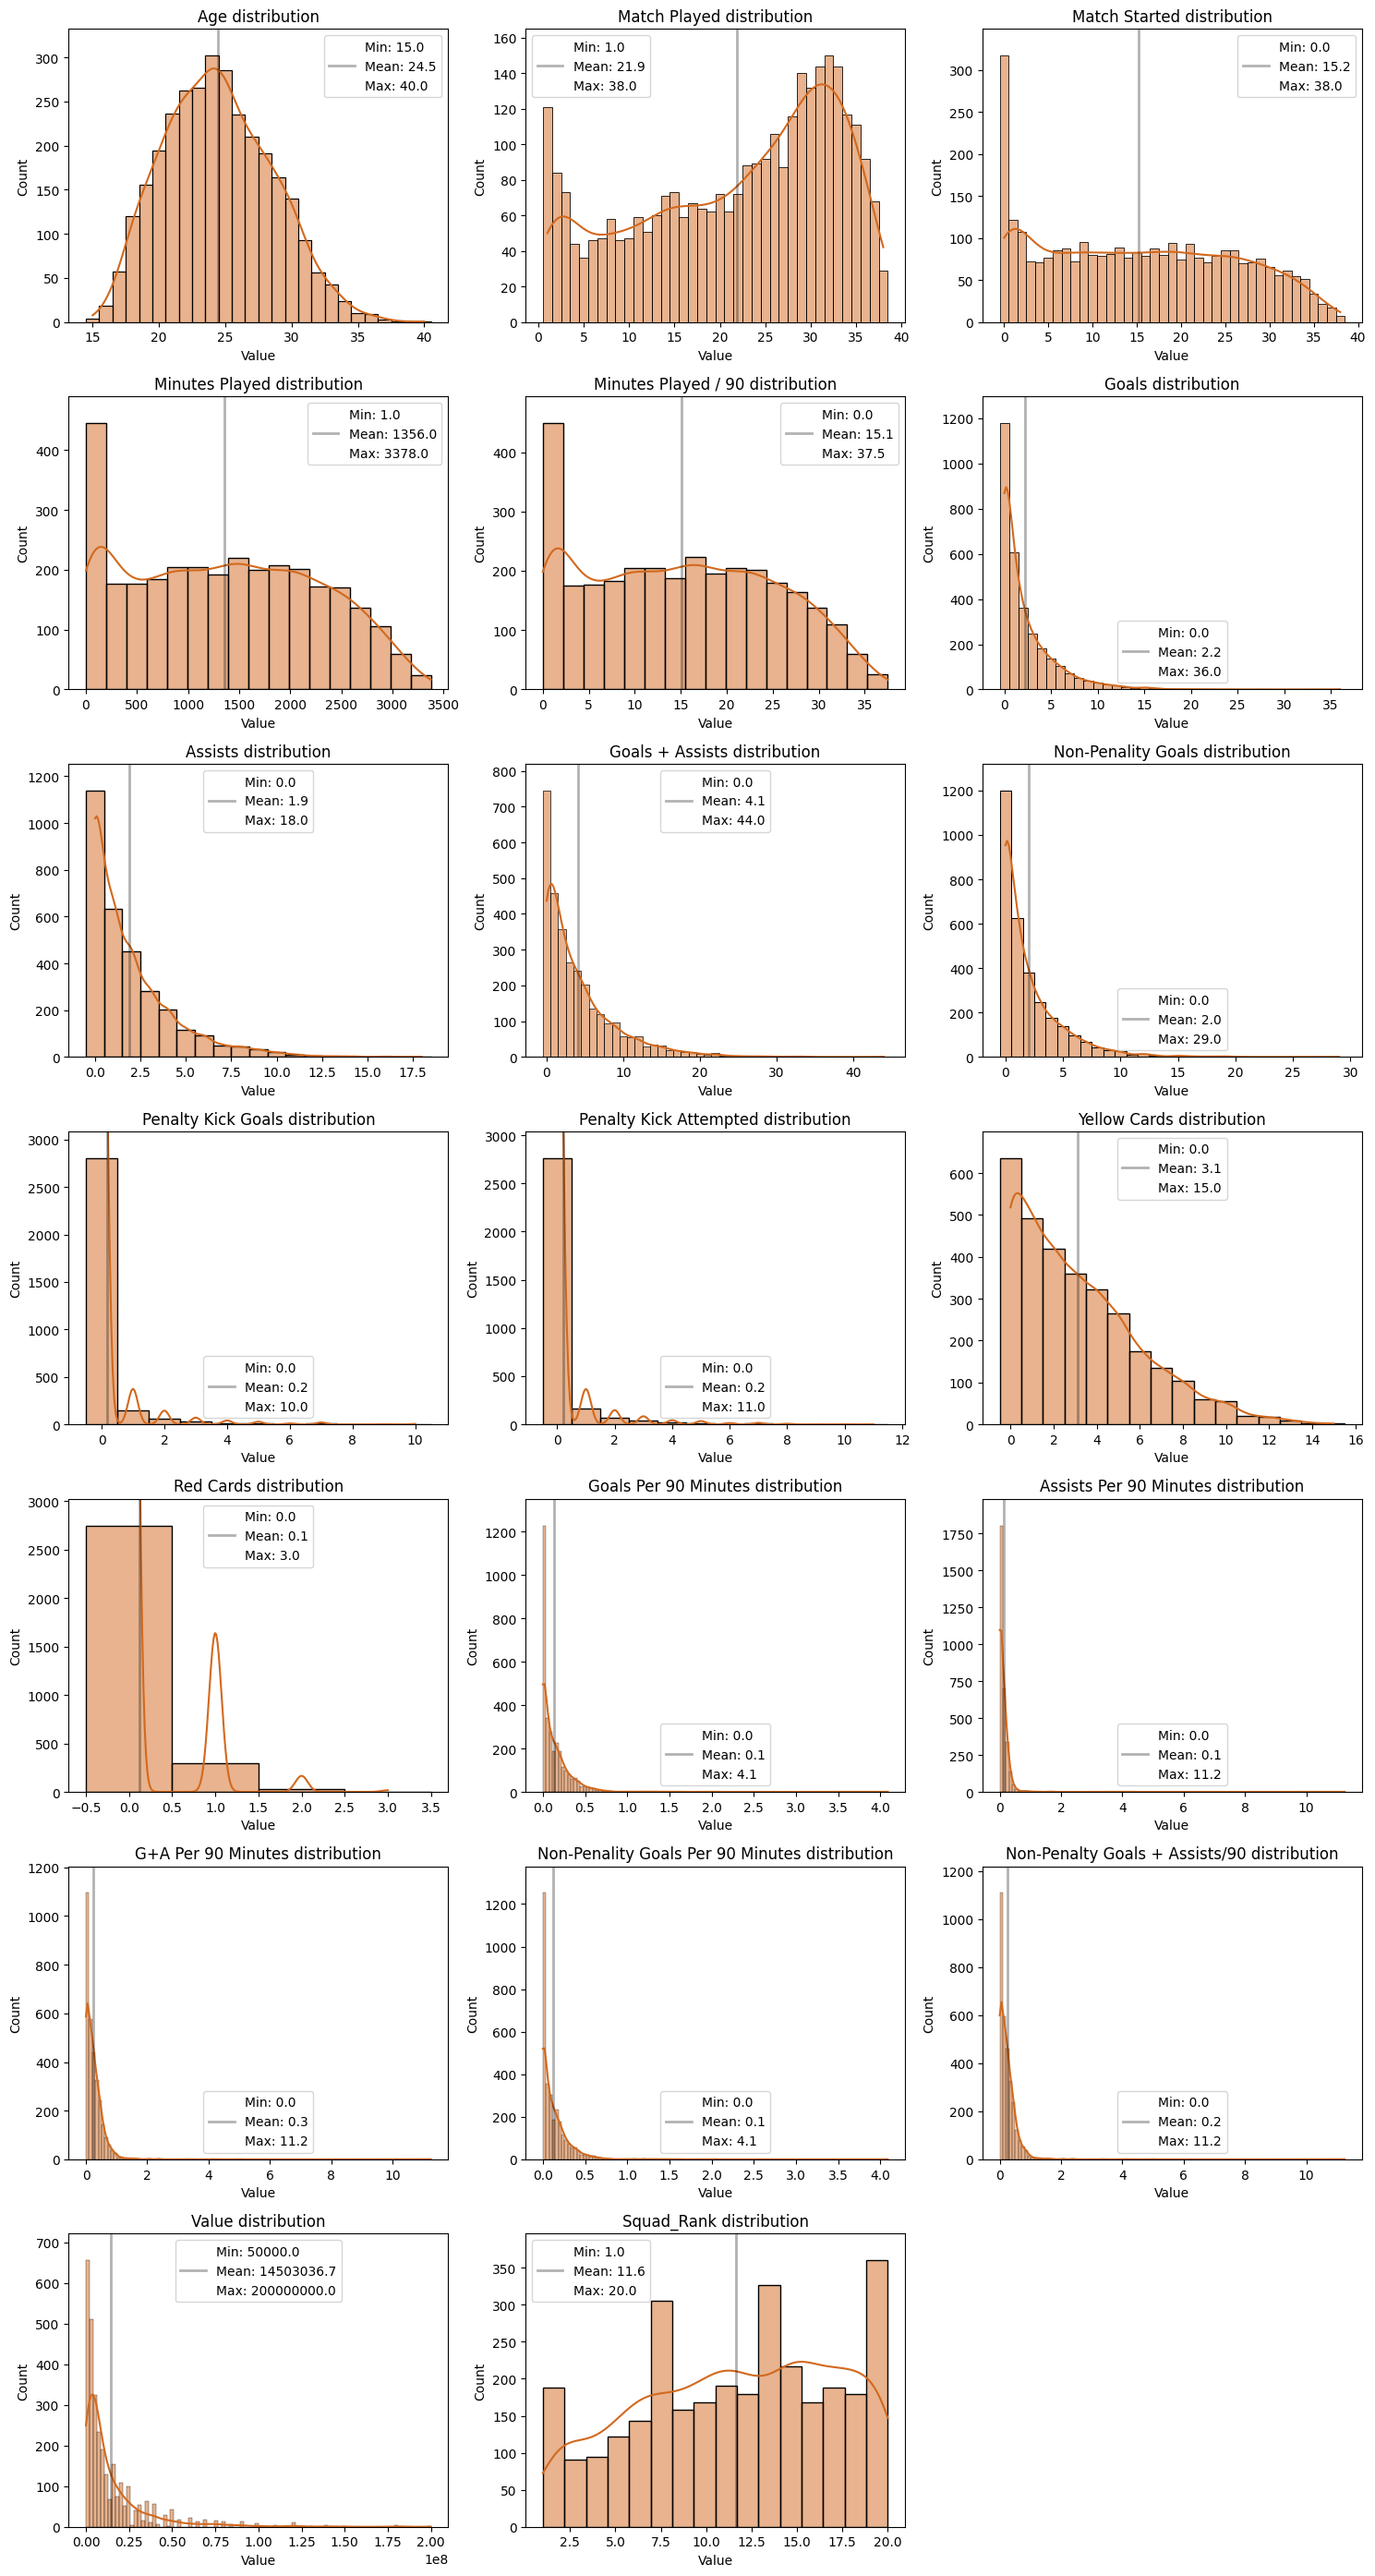

In [403]:
plot_entire_distribution(DF_df, color='chocolate')

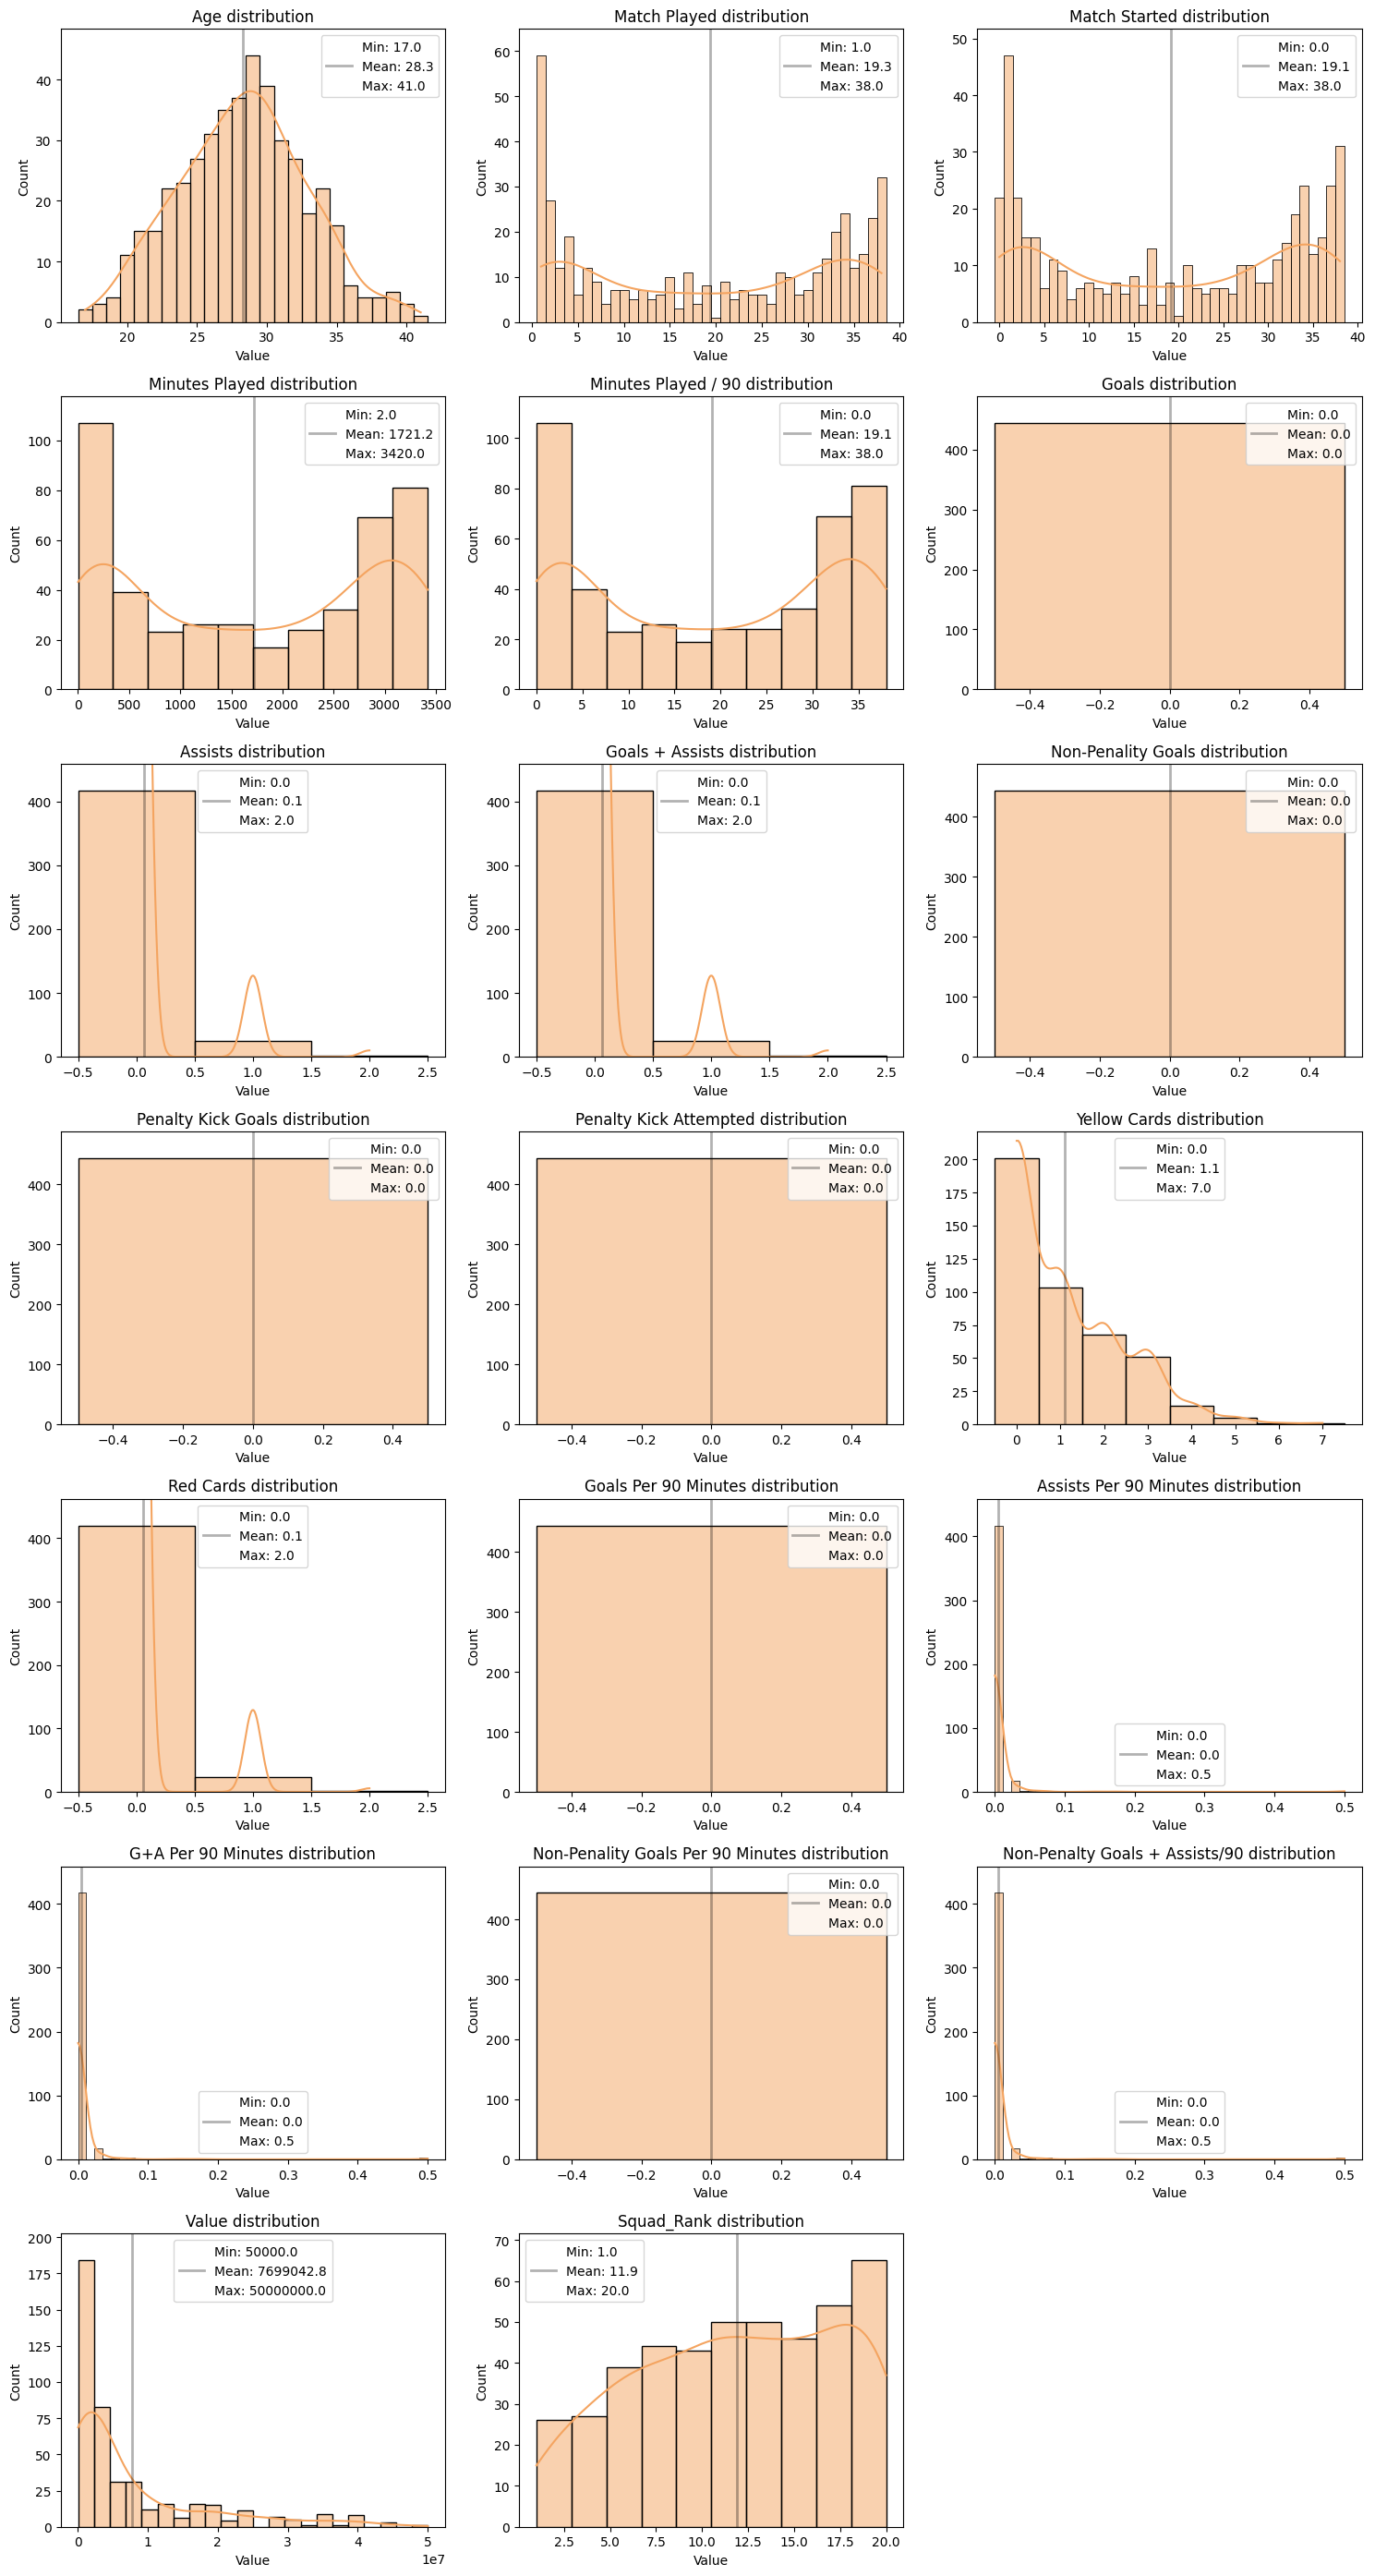

In [404]:
plot_entire_distribution(GK_df, color='sandybrown')